In [10]:
%reload_ext autoreload
%autoreload 2

In [11]:
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import math
import ast
import torch


def get_summary_df(dir_path: str) -> pd.DataFrame:
    """Returns the summary.csv file as a pandas dataframe.

    Args:
        dir_path (str): The path to the directory containing summary.csv.

    Returns:
        pd.DataFrame: The summary dataframe.
    """
    df = None
    while df is None:
        # If another process is writing to the file, it might raise an exception
        try:
            df = pd.read_csv(dir_path + os.sep + "summary.csv")
        except Exception as e:
            print(e)
    return df


def query(
    name: str,
    method: str | list[str] | tuple[str] | None = None,
    estimator: str | list[str] | tuple[str] | None = None,
    embedding_net: str | list[str] | tuple[str] | None = None,
    task: str | list[str] | tuple[str] | None = None,
    num_simulations: int | list[int] | tuple[int] | None = None,
    seed: int | list[int] | tuple[int] | None = None,
    metric: str | list[str] | tuple[str] | None = None,
    reduce_fn: str | None = "auto",
    **kwargs,
) -> pd.DataFrame:
    """Queries the summary.csv file.

    Args:
        name (str): The name of the summary file.
        method (str | list[str] | tuple[str], optional): The method(s) to query. Defaults to None.
        task (str | list[str] | tuple[str], optional): The task(s) to query. Defaults to None.
        num_simulations (int | list[int] | tuple[int], optional): The number of simulation(s) to query. Defaults to None.
        seed (int | list[int] | tuple[int], optional): The seed(s) to query. Defaults to None.
        metric (str | list[str] | tuple[str], optional): The metric(s) to query. Defaults to None.

    Returns:
        pd.DataFrame: The queried summary dataframe.
    """
    summary_df = get_summary_df(name)
    query = ""
    query += to_query_string("method", method)
    query += to_query_string("estimator", estimator)
    query += to_query_string("embedding_net", embedding_net)
    query += to_query_string("task", task)
    query += to_query_string("num_simulations", num_simulations)
    query += to_query_string("seed", seed)
    query += to_query_string("metric", metric)

    if query.endswith(" & "):
        query = query[:-3]
    if query == "":
        df = summary_df
    else:
        print(query)
        df = summary_df.query(query)

    if reduce_fn == "mean":

        def apply_fn(x):
            items = eval(x)
            return sum(items) / len(items)

        df.loc[:, "value"] = df["value"].apply(apply_fn)

    elif reduce_fn == "auto":
        # If metric == c2st/swd/std_dist -> mean
        # If metric == tarp/sbc -> p-value

        def apply_fn(value, metric):
            items = ast.literal_eval(value)
            if metric in ["c2st", "swd", "standardized_distance"]:
                return sum(items) / len(items)
            elif metric == "tarp":
                alpha, ecp = items
                ecp = torch.tensor(ecp)
                alpha = torch.tensor(alpha)
                # TODO: This is not a proper p-value
                # atc, ks_pval = check_tarp(ecp, alpha)
                num_sbc_samples = 1000
                test_stat_ks = torch.max(torch.abs(ecp - alpha))
                ks_pval = np.exp(-2 * test_stat_ks**2 * num_sbc_samples)
                return ks_pval
            elif metric == "sbc":
                ranks = torch.tensor(items)
                if ranks.ndim == 1:
                    ranks = ranks.unsqueeze(-1)
                mum_posterior_samples = ranks.max().item()
                pvals = check_uniformity_frequentist(
                    ranks, num_posterior_samples=mum_posterior_samples
                )
                return pvals
            else:
                return items

        # Apply the function in a single pass
        df["value"] = df.apply(
            lambda row: apply_fn(row["value"], row["metric"]), axis=1
        )

    return df


def to_query_string(name: str, var: any, end: str = " & ") -> str:
    """Translates a variable to string for query.

    Args:
        name (str): The query argument.
        var (any): The value to query.
        end (str, optional): The ending string for the query. Defaults to " & ".

    Returns:
        str: The query string.
    """
    if var is None:
        return ""
    elif (
        var is pd.NA
        or var is torch.nan
        or var is math.nan
        or str(var) == "nan"
        or var is np.nan
    ):
        return f"{name}!={name}"
    elif isinstance(var, list) or isinstance(var, tuple):
        query = "("
        for v in var:
            if query != "(":
                query += "|"
            if isinstance(v, str):
                query += f"{name}=='{v}'"
            else:
                query += f"{name}=={v}"
        query += ")"
    else:
        if isinstance(var, str):
            query = f"({name}=='{var}')"
        else:
            query = f"({name}=={var})"
    return query + end


DEFAULT_COLORS = {
    "nle": "#76b5c5",
    "snle": "#76b5c5",
    "nre": "#1e81b0",
    "snre": "#1e81b0",
    "npe": "#1f77b4",
    "snpe": "#1f77b4",
    "tsnpe": "#1f77b2",
    "tabpfn": "#f2a900",
    "ts_tabpfn": "#f2a900",
    "filtered_tabpfn": "#ff7f0e",
}

_custom_styles = ["pyloric"]
_mpl_styles = list(plt.style.available)
# path to pyloric style file
PATH = os.path.join("../../tabpfn_sbi/utils/")


def get_style(style, **kwargs):
    if style in _mpl_styles:
        return [style]
    elif style in _custom_styles:
        return [PATH + os.sep + style + ".mplstyle"]
    elif style == "science":
        return ["science"]
    elif style == "science_grid":
        return ["science", {"axes.grid": True}]
    elif style is None:
        return None
    else:
        return style


class use_style:
    def __init__(self, style, kwargs={}) -> None:
        super().__init__()
        self.style = get_style(style) + [kwargs]
        self.previous_style = {}

    def __enter__(self):
        self.previous_style = mpl.rcParams.copy()
        if self.style is not None:
            plt.style.use(self.style)

    def __exit__(self, *args, **kwargs):
        mpl.rcParams.update(self.previous_style)
        plt.show()  # Ensure the plot is displayed

In [12]:
from functools import partial

import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pandas as pd

# from tabpfn_sbi.utils import (multi_plot, plot_metric_by_num_simulations,
#                               query, use_style)
# from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS


# Note you need to have the results from the benchmarking in the results folder i.e. run by tabpfnbm!
name = "../../main_results/misspecified"

/var/folders/2h/t5xqz1s51nng4tk1ss1vfn_w0000gn/T/ipykernel_47790/3964045113.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


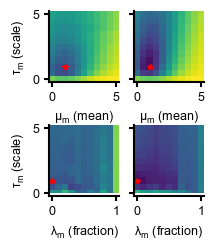

In [ ]:
figsize = (1, 1.2)


def get_c2st_heatmap(name, task, method):
    #
    df = query(name)
    # filter for task and method
    df = df[df["task"] == task]
    df = df[df["method"] == method]

    def extract_data_from_cfg(cfg_str, param):
        cfg_dict = ast.literal_eval(cfg_str)
        # Handle nested parameter path like 'task.params.mu_m'
        curr = cfg_dict
        for key in param.split("."):
            curr = curr[key]
        return curr

    # add columns for tau_m and mu_m/lambda_val
    df["tau_m"] = df["cfg"].apply(
        lambda x: extract_data_from_cfg(x, "task.params.tau_m")
    )
    # Extract parameters based on task
    if task == "misspecified_prior":
        x_param = "mu_m"
        df["mu_m"] = df["cfg"].apply(
            lambda x: extract_data_from_cfg(x, "task.params.mu_m")
        )
    elif task == "misspecified_likelihood":
        x_param = "lambda_val"
        df["lambda_val"] = df["cfg"].apply(
            lambda x: extract_data_from_cfg(x, "task.params.lambda_val")
        )

    # Group by x_param and tau_m, calculate mean c2st over seeds and observations
    pivot_data = df.groupby([x_param, "tau_m"])["value"].mean().reset_index()
    # Reshape to a matrix format for heatmap
    heatmap_data = pivot_data.pivot(index="tau_m", columns=x_param, values="value")
    # Sort index in ascending order to have increasing y-axis values from bottom to top
    heatmap_data = heatmap_data.sort_index(ascending=True)

    return heatmap_data


def plot_c2st_heatmaps():
    heatmap_prior_npe = get_c2st_heatmap(name, "misspecified_prior", "npe")
    heatmap_prior_tabpfn = get_c2st_heatmap(
        name, "misspecified_prior", "filtered_tabpfn"
    )
    heatmap_likelihood_npe = get_c2st_heatmap(name, "misspecified_likelihood", "npe")
    heatmap_likelihood_tabpfn = get_c2st_heatmap(
        name, "misspecified_likelihood", "filtered_tabpfn"
    )

    # Create the plot
    with use_style("pyloric"):
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(2 * figsize[0], 2 * figsize[1]),
            sharex=False,
            sharey=True,
            gridspec_kw={"hspace": 0.6},
        )

        def plot_individual(ax, heatmap_data, task, method):
            data = heatmap_data.values
            x_vals = np.array(heatmap_data.columns)
            y_vals = np.array(heatmap_data.index)

            X, Y = np.meshgrid(x_vals, y_vals)
            pcm = ax.pcolormesh(
                X,
                Y,
                data,
                cmap="viridis",  # 'jet', 'viridis', 'inferno', 'magma'
                vmin=0.5,
                vmax=1.0,
            )

            # Select only three ticks: lowest, middle, and highest
            x_indices = [0, len(x_vals) - 1]  # len(x_vals)//2,
            y_indices = [0, len(y_vals) - 1]  # len(y_vals)//2,

            # Set ticks at the actual data values
            ax.set_xticks([x_vals[i] for i in x_indices])
            ax.set_yticks([y_vals[i] for i in y_indices])
            # Set x tick labels: first and last as integers, middle with empty label
            x_tick_labels = [
                str(int(x_vals[x_indices[0]])),
                str(int(x_vals[x_indices[1]])),
            ]
            ax.set_xticklabels(x_tick_labels)
            # Replace 0.05 with 0.0 in y-tick labels if present
            y_tick_labels = [
                str(int(y_vals[y_indices[0]])),
                str(int(y_vals[y_indices[1]])),
            ]
            ax.set_yticklabels(y_tick_labels)

            # Add red star marker at the correct data values
            ax.plot(1.0 if task == "prior" else 0.0, 1.0, "r*", markersize=4)

            # replace 'lambda_val' with 'lambda'
            x_param = (
                "$\\lambda_m$ (fraction)" if task == "likelihood" else "$\\mu_m$ (mean)"
            )
            y_param = "$\\tau_m$ (scale)"

            ax.set_xlabel(f"{x_param}")
            ax.set_ylabel(f"{y_param}") if method == "npe" else ax.set_ylabel("")
            return ax

        axs[0, 0] = plot_individual(axs[0, 0], heatmap_prior_npe, "prior", "npe")
        axs[0, 1] = plot_individual(axs[0, 1], heatmap_prior_tabpfn, "prior", "tabpfn")
        axs[1, 0] = plot_individual(
            axs[1, 0], heatmap_likelihood_npe, "likelihood", "npe"
        )
        axs[1, 1] = plot_individual(
            axs[1, 1], heatmap_likelihood_tabpfn, "likelihood", "tabpfn"
        )

        plt.tight_layout()
        plt.show()
        fig.savefig(f"figmisspecified_main.svg", bbox_inches="tight", transparent=True)
        plt.close()


plot_c2st_heatmaps()

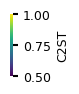

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np


with use_style("pyloric"):
    fig = plt.figure(figsize=(1.0, 0.8))

    # Create an axes object first
    ax = fig.gca()
    ax.set_visible(False)  # Hide the axes

    # Create a dummy mappable object for the colorbar with values between 0.5 and 1.0
    dummy_cmap = plt.cm.viridis
    dummy_norm = colors.Normalize(vmin=0.5, vmax=1.0)
    dummy_sm = plt.cm.ScalarMappable(cmap=dummy_cmap, norm=dummy_norm)
    dummy_sm.set_array([])

    # Create the colorbar and attach it to the axes
    cbar = plt.colorbar(dummy_sm, ax=ax)

    # Remove the border surrounding the colors
    cbar.outline.set_visible(False)

    # Make font smaller for colorbar ticklabels
    cbar.ax.tick_params()  # labelsize=6)

    # Add C2ST label
    cbar.set_label("C2ST")  # , size=9)

    # Save the figure
    fig.savefig("colorbar.svg", bbox_inches="tight", transparent=True)

/var/folders/2h/t5xqz1s51nng4tk1ss1vfn_w0000gn/T/ipykernel_47790/2272935648.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


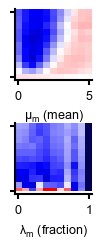

In [16]:
def plot_c2st_heatmaps_diff():
    heatmap_prior_npe = get_c2st_heatmap(name, "misspecified_prior", "npe")
    heatmap_prior_tabpfn = get_c2st_heatmap(
        name, "misspecified_prior", "filtered_tabpfn"
    )
    heatmap_likelihood_npe = get_c2st_heatmap(name, "misspecified_likelihood", "npe")
    heatmap_likelihood_tabpfn = get_c2st_heatmap(
        name, "misspecified_likelihood", "filtered_tabpfn"
    )

    diff_prior = heatmap_prior_tabpfn - heatmap_prior_npe
    diff_likelihood = heatmap_likelihood_tabpfn - heatmap_likelihood_npe

    # Create the plot
    with use_style("pyloric"):
        fig, axs = plt.subplots(
            2,
            1,
            figsize=(figsize[0], 2 * figsize[1]),
            sharex=False,
            sharey=True,
            gridspec_kw={"hspace": 0.6},
        )

        def plot_individual(ax, heatmap_data, task, method):
            data = heatmap_data.values
            x_vals = np.array(heatmap_data.columns)
            y_vals = np.array(heatmap_data.index)

            X, Y = np.meshgrid(x_vals, y_vals)
            pcm = ax.pcolormesh(X, Y, data, cmap="seismic", vmin=-0.2, vmax=0.2)

            # Select only three ticks: lowest, middle, and highest
            x_indices = [0, len(x_vals) - 1]  # len(x_vals)//2,
            y_indices = [0, len(y_vals) - 1]  # len(y_vals)//2,

            # Set ticks at the actual data values
            ax.set_xticks([x_vals[i] for i in x_indices])
            ax.set_yticks([y_vals[i] for i in y_indices])
            # Set x tick labels: first and last as integers, middle with empty label
            x_tick_labels = [
                str(int(x_vals[x_indices[0]])),
                str(int(x_vals[x_indices[1]])),
            ]
            ax.set_xticklabels(x_tick_labels)
            # Replace 0.05 with 0.0 in y-tick labels if present
            y_tick_labels = [
                str(int(y_vals[y_indices[0]])),
                str(int(y_vals[y_indices[1]])),
            ]
            ax.set_yticklabels([])  # y_tick_labels)

            # replace 'lambda_val' with 'lambda'
            x_param = (
                "$\\lambda_m$ (fraction)" if task == "likelihood" else "$\\mu_m$ (mean)"
            )
            y_param = "$\\tau_m$ (scale)"

            ax.set_xlabel(f"{x_param}")
            # ax.set_ylabel(f'{y_param}') if method == 'npe' else ax.set_ylabel('')
            return ax

        axs[0] = plot_individual(axs[0], diff_prior, "prior", "npe")
        axs[1] = plot_individual(axs[1], diff_likelihood, "likelihood", "npe")

        plt.tight_layout()
        plt.show()
        fig.savefig(f"figmisspecified_diff.svg", bbox_inches="tight", transparent=True)
        plt.close()


plot_c2st_heatmaps_diff()

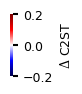

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np


with use_style("pyloric"):
    fig = plt.figure(figsize=(1.0, 0.8))

    # Create an axes object first
    ax = fig.gca()
    ax.set_visible(False)  # Hide the axes

    # Create a dummy mappable object for the colorbar with values between 0.5 and 1.0
    dummy_cmap = plt.cm.seismic
    dummy_norm = colors.Normalize(vmin=-0.2, vmax=0.2)
    dummy_sm = plt.cm.ScalarMappable(cmap=dummy_cmap, norm=dummy_norm)
    dummy_sm.set_array([])

    # Create the colorbar and attach it to the axes
    cbar = plt.colorbar(dummy_sm, ax=ax, location="right")

    # Move ticks to the left side of the colorbar
    cbar.ax.yaxis.set_ticks_position("right")

    # Remove the border surrounding the colors
    cbar.outline.set_visible(False)

    # Make font smaller for colorbar ticklabels
    cbar.ax.tick_params()  # labelsize=6)

    # Add C2ST label
    cbar.set_label("$\\Delta$ C2ST")  # , size=9)

    # Save the figure
    fig.savefig("colorbar_diff.svg", bbox_inches="tight", transparent=True)